# Model Comparison

Ce notebook compare les 4 modèles utilisés dans ce projet :
- **Logistic Regression**  baseline linéaire supervisé
- **Random Forest**  méthode d'ensemble supervisée
- **XGBoost**  boosting supervisé
- **K-Means** clustering non supervisé

Les 3 premiers résolvent la même tâche de **classification binaire** et sont comparés sur les mêmes métriques. K-Means répond à un objectif différent (segmentation) et est évalué séparément.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, silhouette_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/UCI_Credit_Card.csv')
target_col = 'default.payment.next.month'

X = df.drop(columns=['ID', target_col])
y = df[target_col]
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)
X_all_scaled   = scaler.transform(X)

print("Data ready.")

Data ready.


## Justification du choix des modèles

| Modèle | Justification |
|---|---|
| **Logistic Regression** | Simple, rapide, interprétable. Permet de voir si un modèle linéaire suffit pour ce problème. |
| **Random Forest** | Méthode d'ensemble par bagging. Robuste aux outliers, gère bien les features corrélées, fournit des feature importances. |
| **XGBoost** | Méthode d'ensemble par boosting. Généralement plus performant que RF sur des données tabulaires structurées. |
| **K-Means** | Méthode non supervisée. Ne prédit pas le défaut mais segmente les clients en groupes homogènes pour mieux comprendre la structure des données. |

La tâche est une **classification binaire** : prédire si un client fera défaut (1) ou non (0). Le F1 Score et l'AUC-ROC sont les métriques principales car le dataset est déséquilibré (~22% de défauts).

In [2]:
models = {
    'Logistic Regression': LogisticRegression(C=1, solver='lbfgs', max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, criterion='entropy',
                                                  min_samples_split=5, min_samples_leaf=2,
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                         subsample=0.9, colsample_bytree=0.9,
                                         random_state=42, n_jobs=-1, eval_metric='logloss')
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob)
    }
    print(f"{name} — done")

results_df = pd.DataFrame(results).T.round(4)
display(results_df)

Logistic Regression — done
Random Forest — done
XGBoost — done


,Accuracy,F1 Score,Precision,Recall,AUC-ROC
Logistic Regression,0.8112,0.4698,0.6198,0.3783,0.7061
Random Forest,0.8043,0.4974,0.5758,0.4378,0.7560
XGBoost,0.8127,0.4964,0.6122,0.4175,0.7682


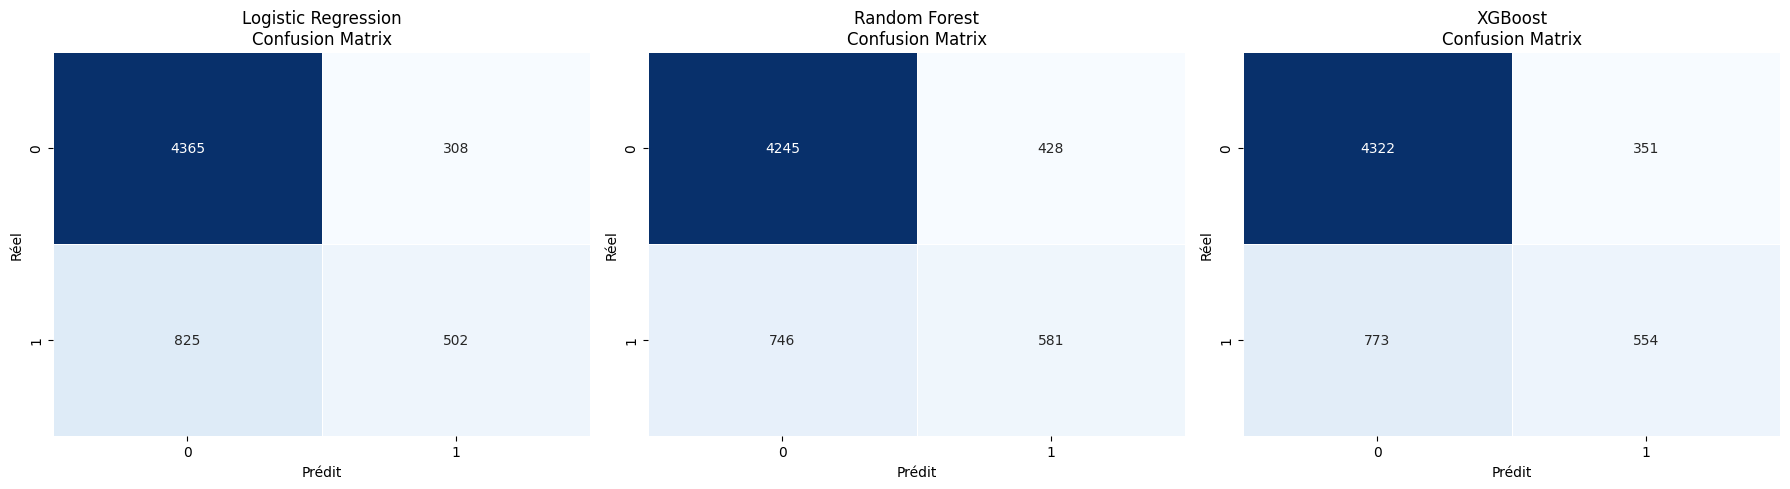

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

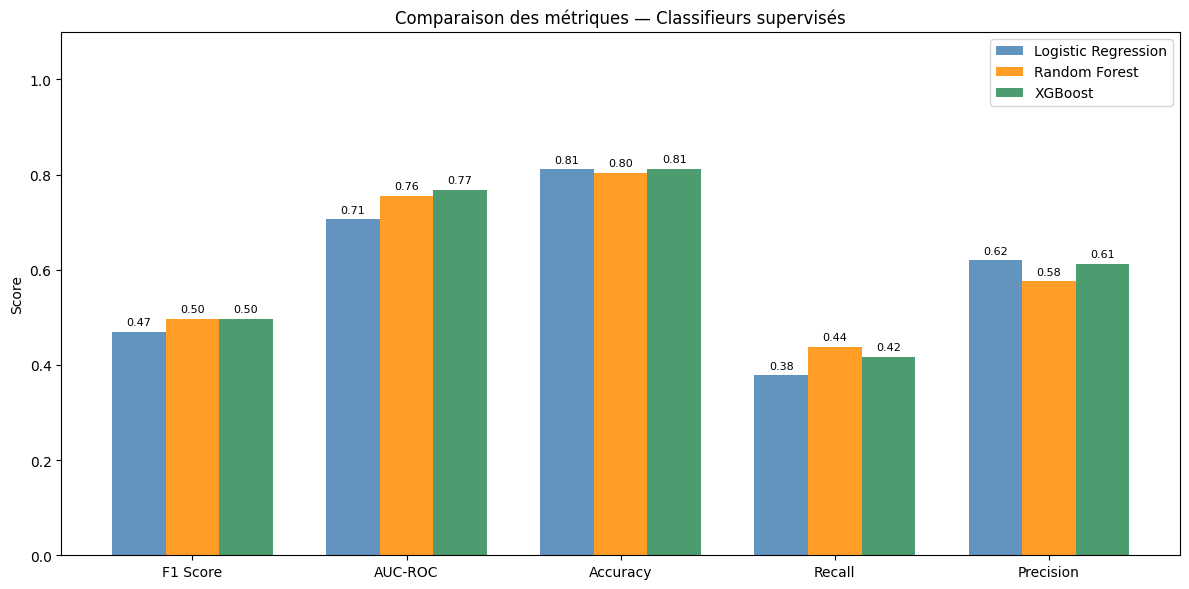

In [4]:
metrics_to_plot = ['F1 Score', 'AUC-ROC', 'Accuracy', 'Recall', 'Precision']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des métriques — Classifieurs supervisés')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_scaled)
sil = silhouette_score(X_all_scaled, cluster_labels, sample_size=5000, random_state=42)

df_c = df.copy()
df_c['Cluster'] = cluster_labels
cluster_default = df_c.groupby('Cluster')[target_col].mean()

print(f"K-Means (non supervisé) — Silhouette Score: {sil:.4f}")
print(f"\nTaux de défaut par cluster:")
print(cluster_default.round(4).to_string())
print(f"\nTaille des clusters:")
print(pd.Series(cluster_labels).value_counts().sort_index().to_string())

K-Means (non supervisé) — Silhouette Score: 0.3063

Taux de défaut par cluster:
Cluster
0    0.2042
1    0.2242

Taille des clusters:
0     4539
1    25461


## Conclusion

### Classifieurs supervisés

Les trois modèles supervisés résolvent la même tâche : prédire le défaut de paiement, mais avec des performances différentes. La **Logistic Regression** sert de baseline : ses résultats linéaires sont corrects mais limités face à la complexité des données. Le **Random Forest** apporte un gain grâce au bagging et à la sélection aléatoire des features. **XGBoost**, grâce au boosting itératif, est généralement le plus performant sur les données tabulaires déséquilibrées.

Sur ce dataset, le F1 Score est la métrique la plus pertinente : l'accuracy seule est trompeuse car prédire systématiquement "pas de défaut" donne déjà 78%. Le modèle qui maximise le F1 sur la classe 1 est donc le plus utile en pratique.

### K-Means (non supervisé)

K-Means ne peut pas être comparé directement aux classifieurs car il n'utilise pas les labels. Son rôle est complémentaire : il révèle que les clients se divisent naturellement en deux profils (un petit groupe d'environ 4 500 clients à comportement financier distinct, et un grand groupe de 25 000+). Les taux de défaut similaires entre clusters (~20-22%) confirment que le clustering capture la structure générale du portefeuille plutôt que le risque de défaut directement.

### Recommandation

Pour un déploiement opérationnel, **XGBoost** est le modèle à privilégier pour la prédiction de défaut. La segmentation K-Means peut être utilisée en parallèle pour personnaliser les actions de la banque selon le profil client (limite de crédit, habitudes de paiement) indépendamment du score de risque.